In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import pandas as pd
import seaborn as sns

In [2]:
import graphufs
from graphufs.lineplot import LinePlotter

In [3]:
plt.style.use("graphufs.plotstyle")

In [6]:
scratch = "/pscratch/sd/n/nagarwal"
fig_dir = os.path.join(os.getcwd(), "figures")

In [5]:
truths = ["Replay"]
models = [
    "ocn-only R4 best-hyperparam-6h",
    "ocn-only R5 best-hyperparam-24h",
]

In [7]:
duration = "240h"
errors = {}

for model in models:
    model_type, expt, description = model.split(" ")
    location = os.path.join(scratch, model_type, expt, "inference/validation/")

    for truth in truths:
        tname = truth.lower()
        errors[truth] = {}
            
        fname = f"{location}/{readname}_vs_{tname}_{middle}_deterministic.nc"
        if not (truth.lower() == "replay" and readname in ("graphcast", "ifs_ens_mean", "replay")):
            kk = model if model != "GraphUFS p2p uvwc" else "GraphUFS p2c"
            errors[truth][kk] = graphufs.utils.open_dataset(fname)


In [8]:
lp = LinePlotter()

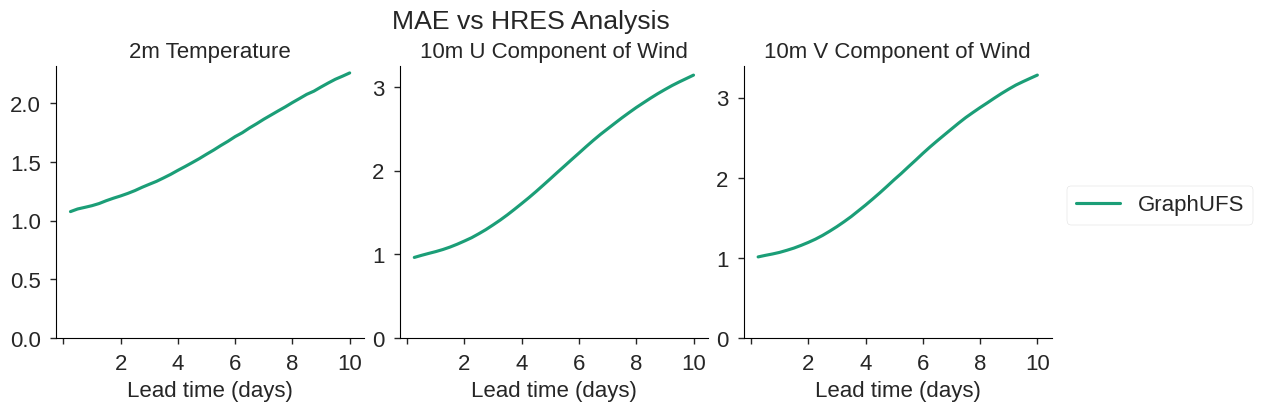

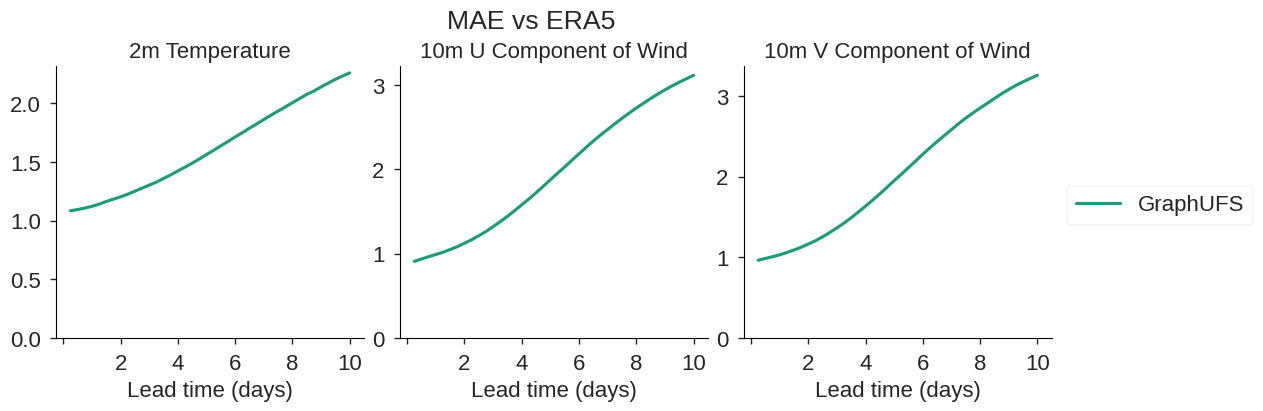

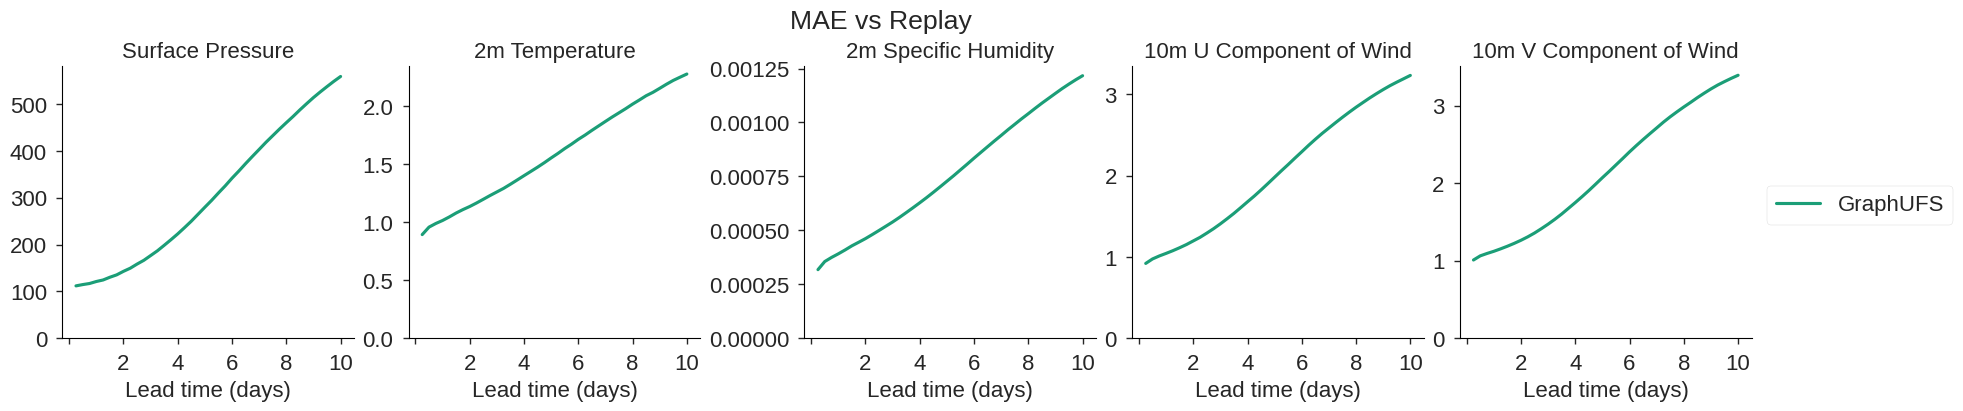

In [15]:
metric = "mae"
for truth in truths:
    kw = {}
    if truth == "Replay":
        kw["fields"] = ("surface_pressure", "2m_temperature", "2m_specific_humidity", "10m_u_component_of_wind", "10m_v_component_of_wind")
    else:
        kw["fields"] = ("2m_temperature", "10m_u_component_of_wind", "10m_v_component_of_wind")
    fig, axs = lp.plot_surface(
        errors[truth],
        truth=truth,
        metric=metric,
        **kw
    )
    [ax.set(xticks=np.arange(0, 11*24, 2*24)) for ax in axs]
    fname = f"{fig_dir_loc}/{metric.upper()}_vs_{truth.lower().replace(' ', '_')}_atm_only_{_expt}_surface.jpeg"
    #fig.savefig(fname, bbox_inches="tight", dpi=300)

/global/homes/n/nagarwal/graph-ufs/graphufs/lineplot.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc="center left", bbox_to_anchor=(1, .5))


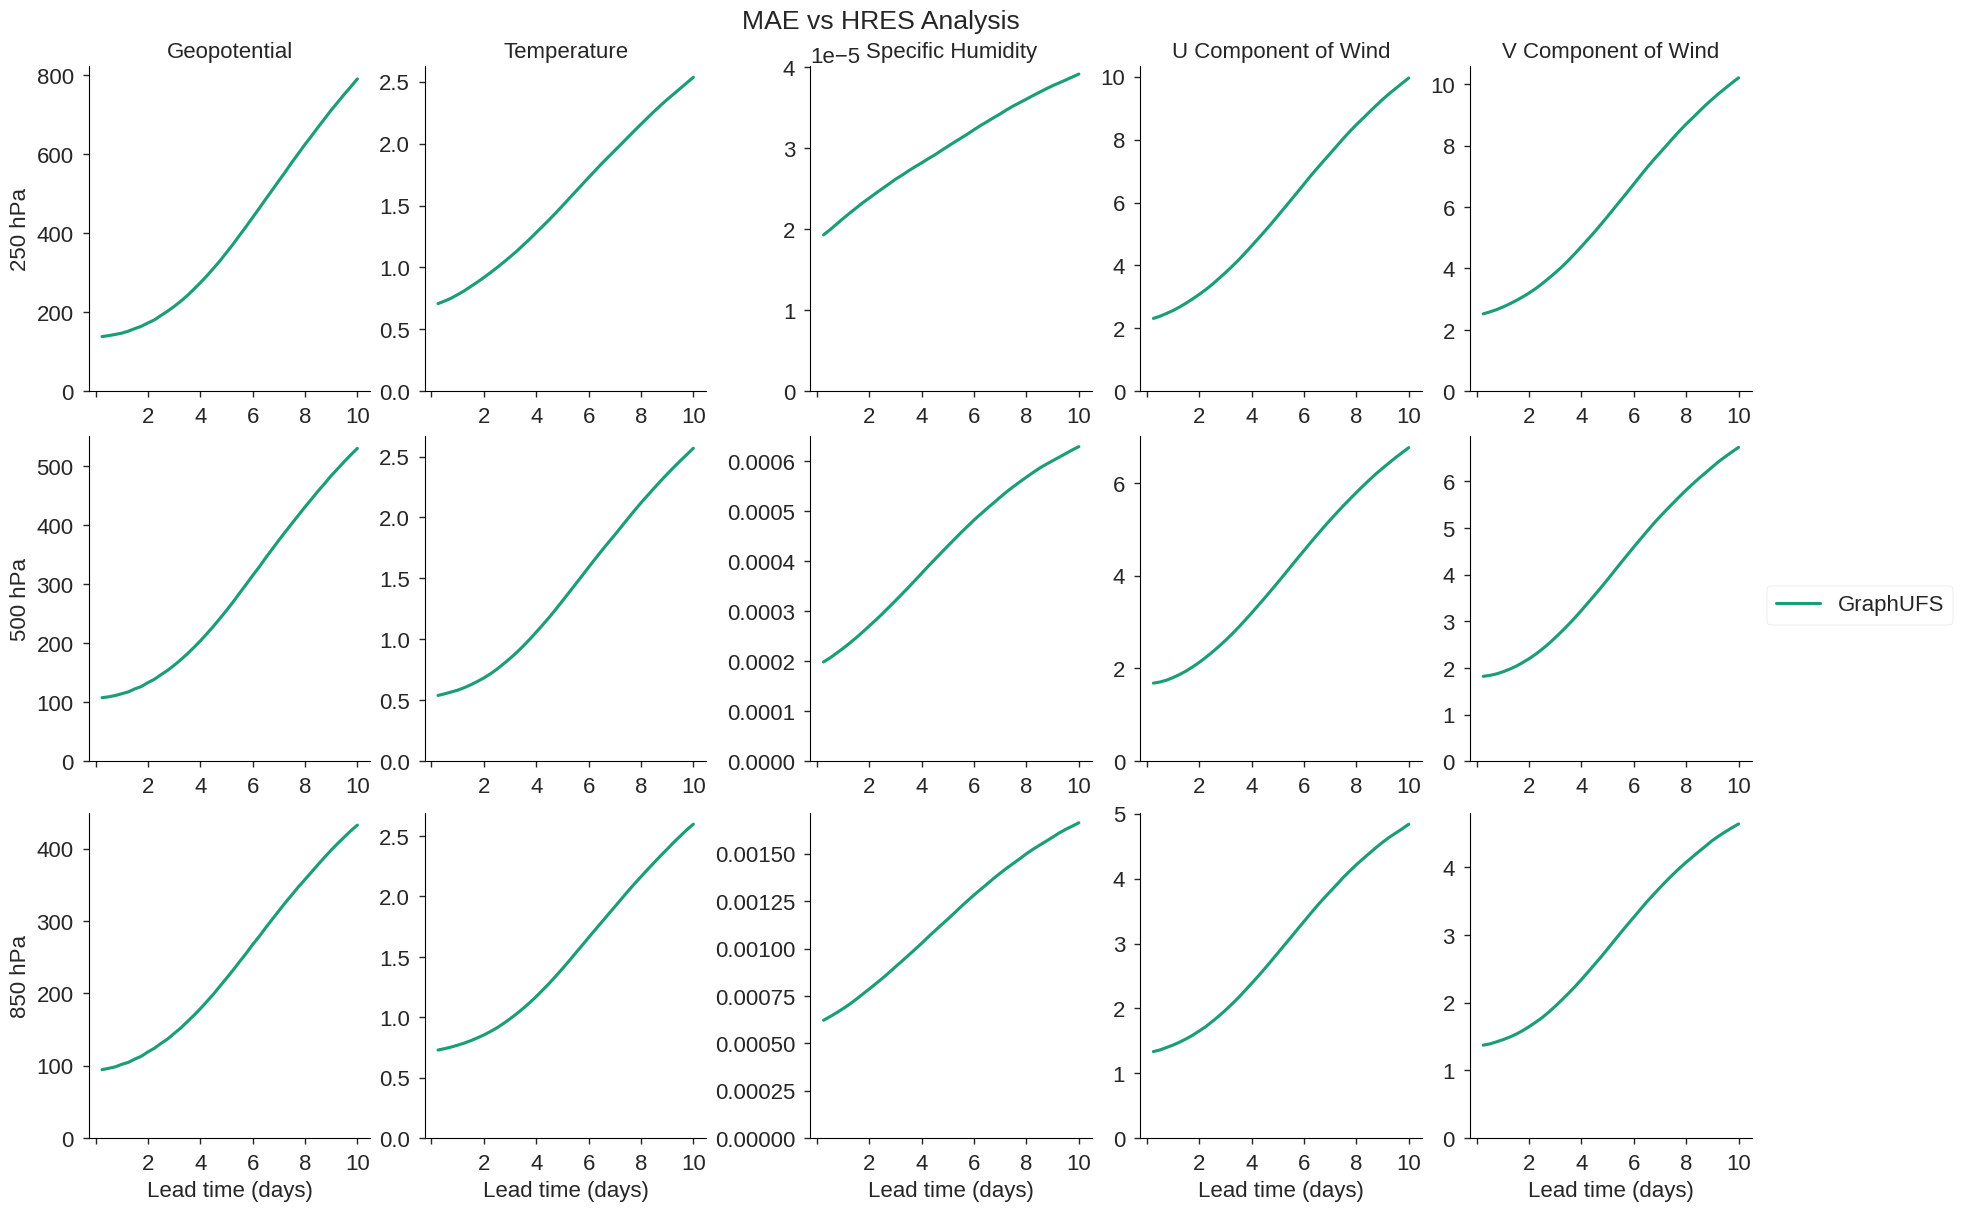

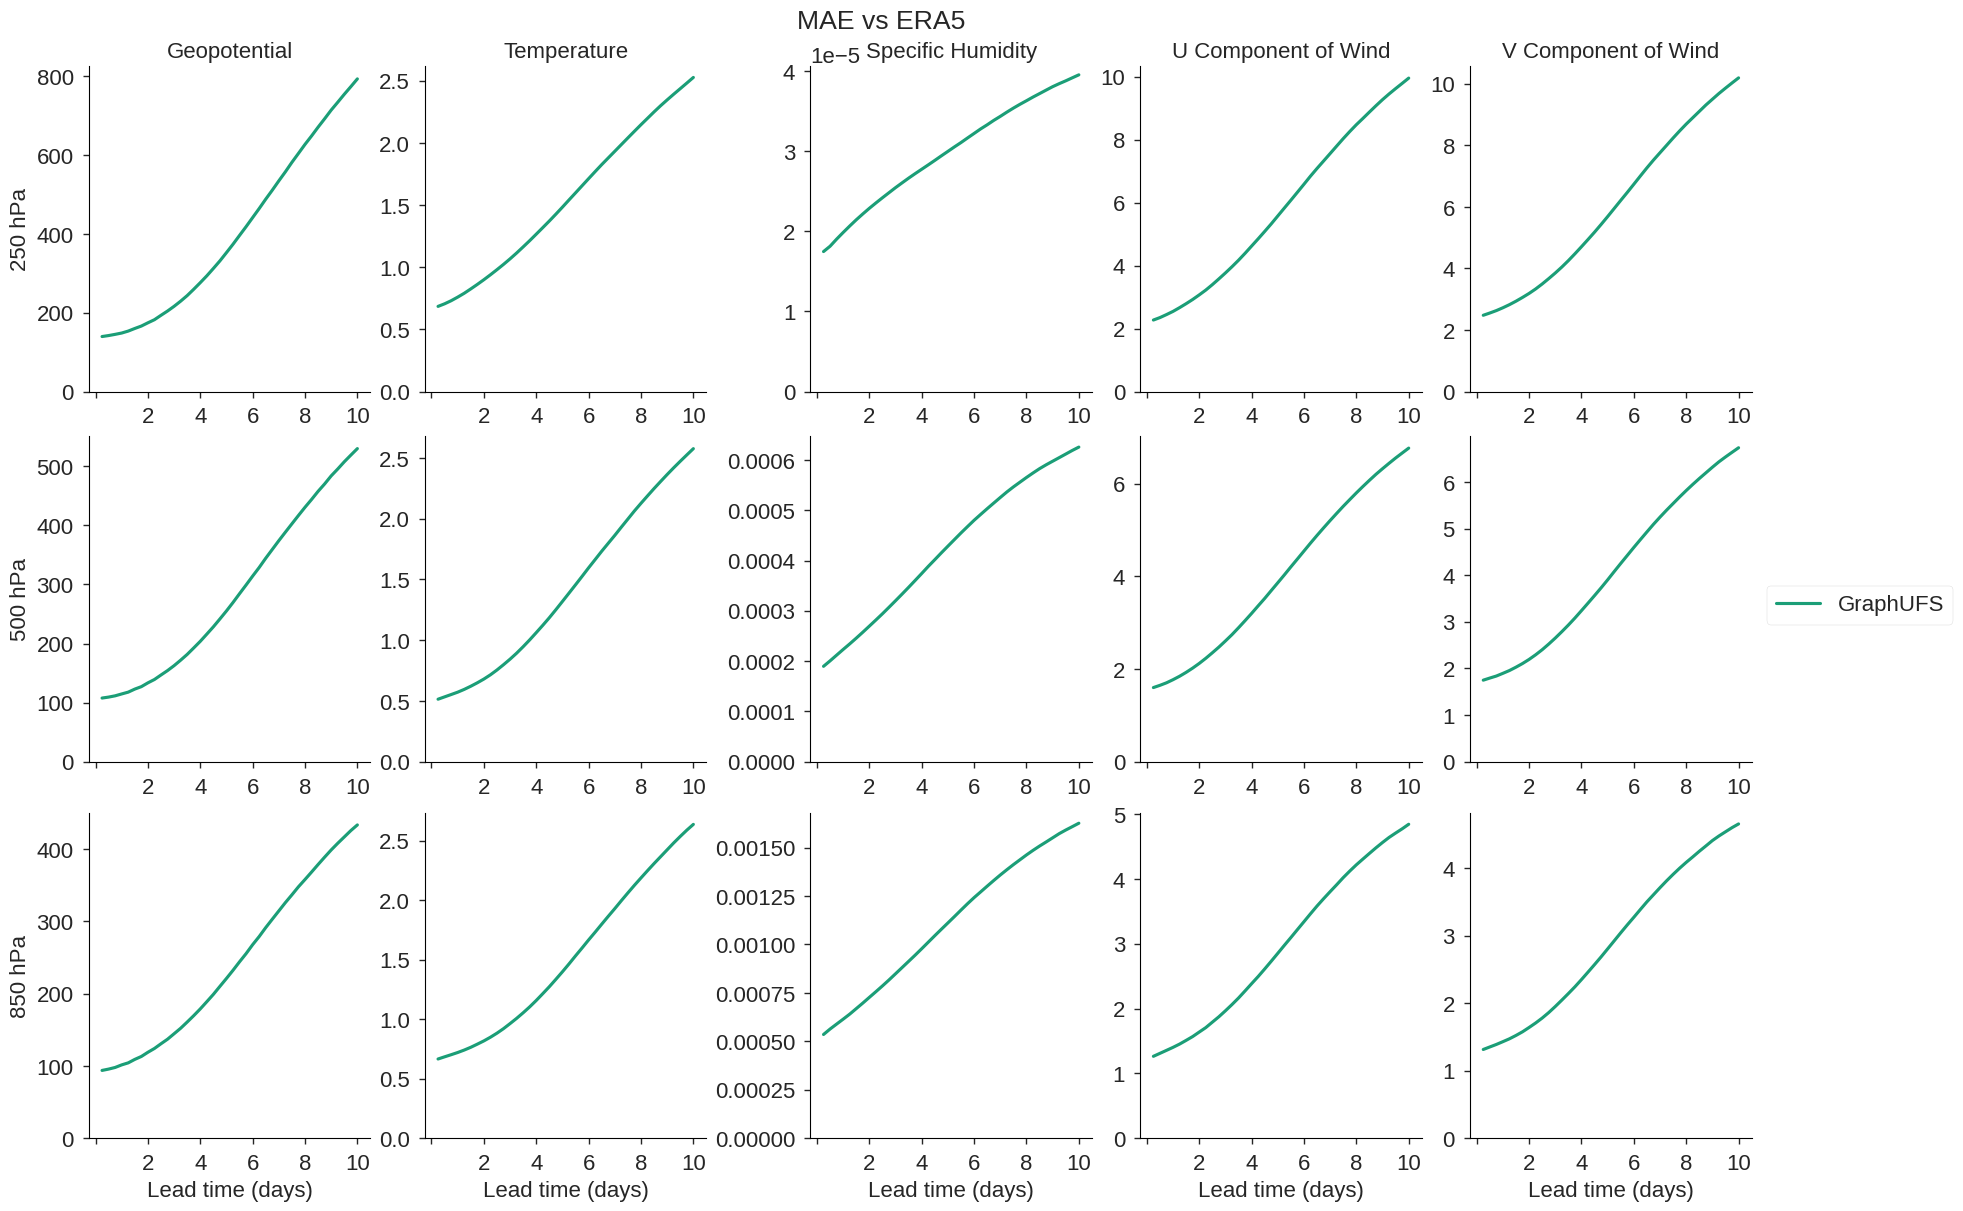

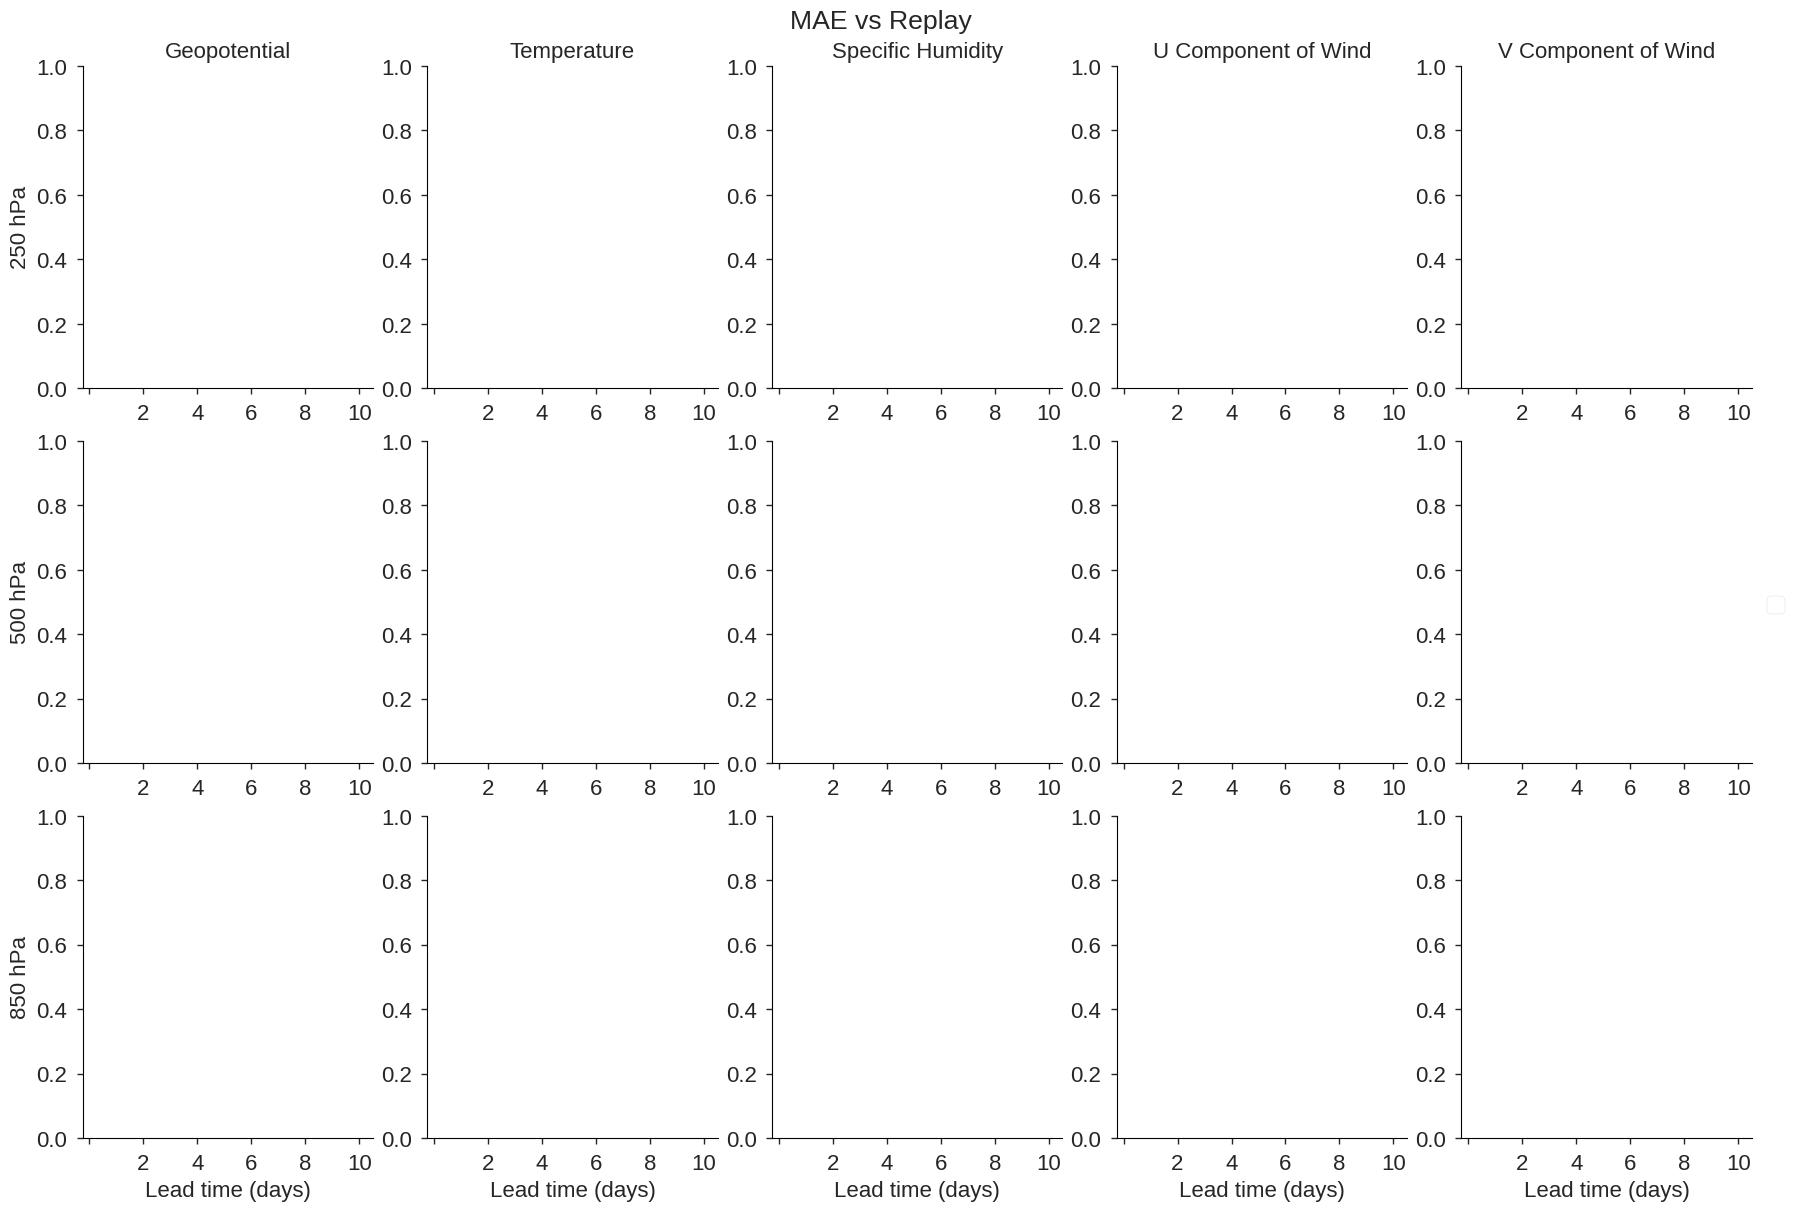

In [16]:
kw = dict(
    levels=(250, 500, 850),
    fields=("geopotential", "temperature", "specific_humidity", "u_component_of_wind", "v_component_of_wind"),
)

for truth in truths:
    fig, axs = lp.plot_levels(
        errors[truth],
        truth=truth,
        metric=metric,
        **kw,
    )
    [ax.set(xticks=np.arange(0, 11*24, 2*24)) for ax in axs.flatten()]
    fname = f"{fig_dir_loc}/{metric}_vs_{truth.lower().replace(' ', '_')}_atm_only_{_expt}_levels.jpeg"
    #fig.savefig(fname, bbox_inches="tight", dpi=300)